In [ ]:
import os, math, numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.nn.utils import spectral_norm, clip_grad_norm_
from sklearn.preprocessing import OneHotEncoder, QuantileTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from dataclasses import dataclass
from typing import Optional, Callable
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, chi2_contingency, entropy
from scipy.spatial.distance import jensenshannon
import warnings
warnings.filterwarnings('ignore')

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cpu


In [21]:
df=pd.read_csv("/kaggle/input/datasets/toshangupta/adult-dataset/adult.csv")
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)
syn_df=pd.read_csv("/kaggle/input/datasets/toshangupta/harpoon-adult-synthetic/harpoon_ordinal_adult_n45000.csv")
syn_df = syn_df.rename(columns={"sex": "gender"})
for col in syn_df.select_dtypes(include='object').columns:
    syn_df[col] = syn_df[col].str.strip()
syn_df.replace('?', np.nan, inplace=True)
syn_df.dropna(inplace=True)
syn_df = syn_df[df.columns]
# syn_df=syn_df.drop(columns=["Unnamed: 0"])
label_col = "income"  

In [22]:
num_cols=['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss','hours-per-week']
cat_cols=['workclass', 'education', 'marital-status', 'occupation','relationship', 'race', 'gender', 'native-country', 'income']

In [23]:
out_dir="Results"
os.makedirs(out_dir, exist_ok=True)


Plotting distribution comparisons...


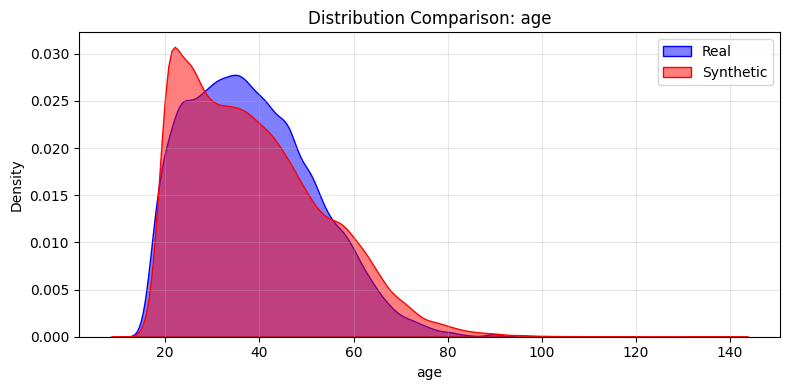

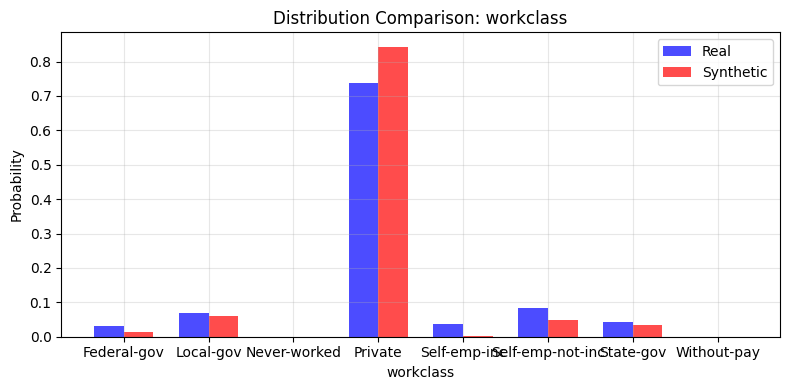

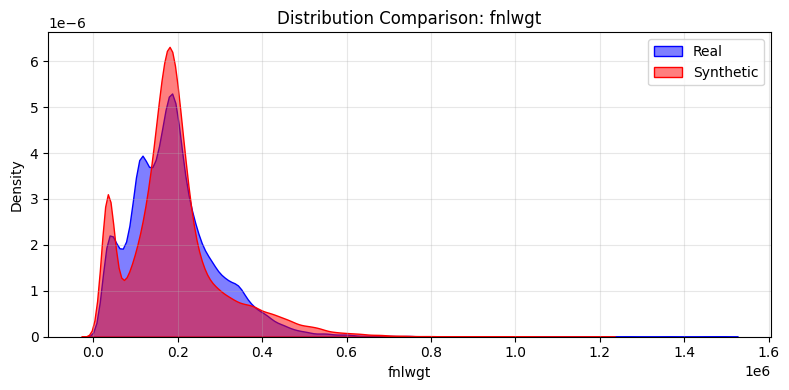

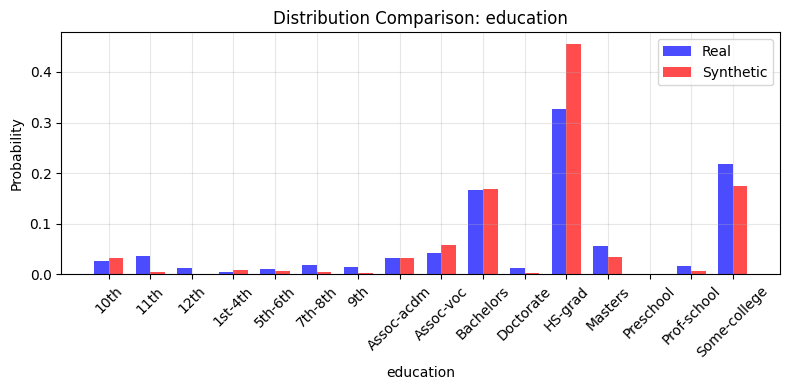

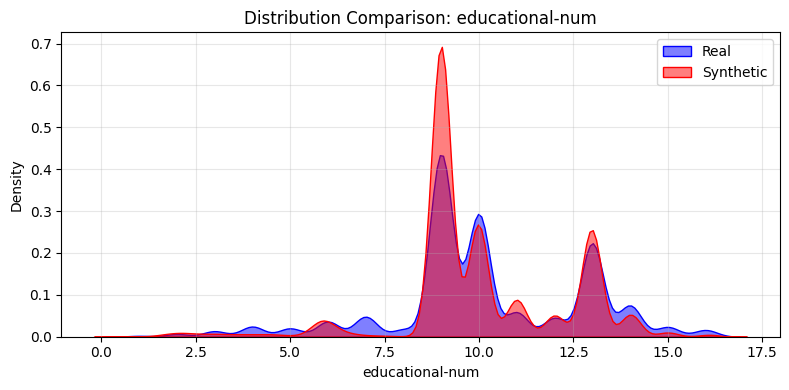

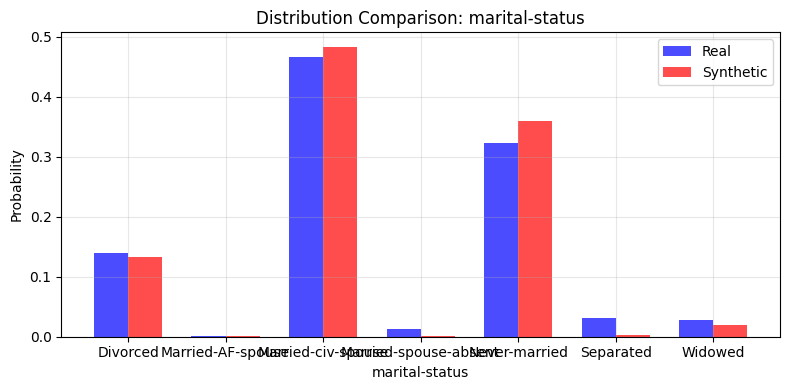

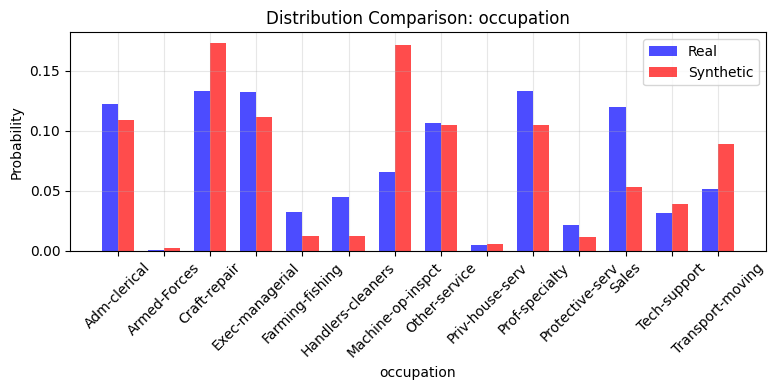

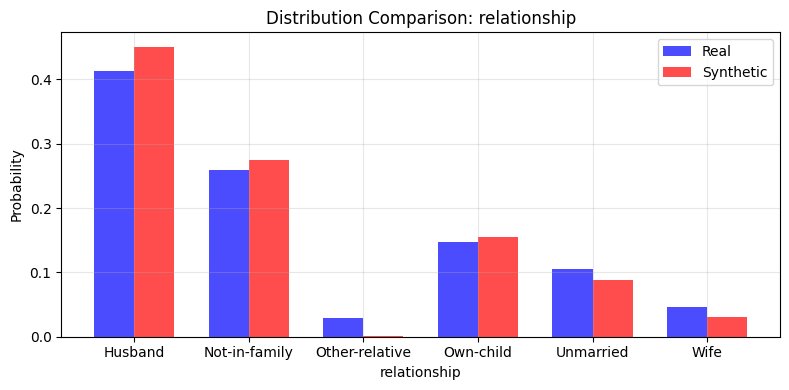

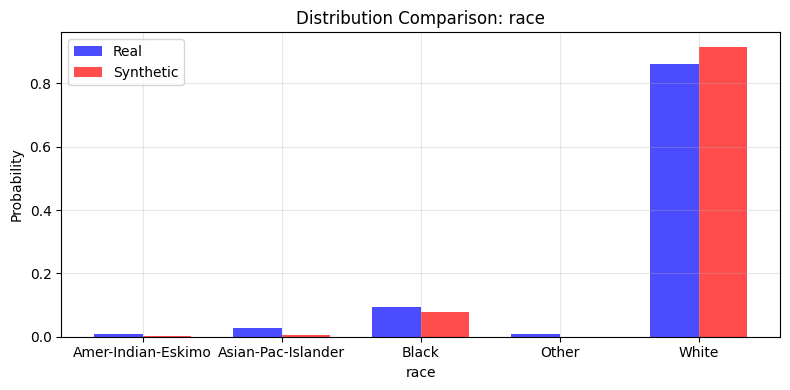

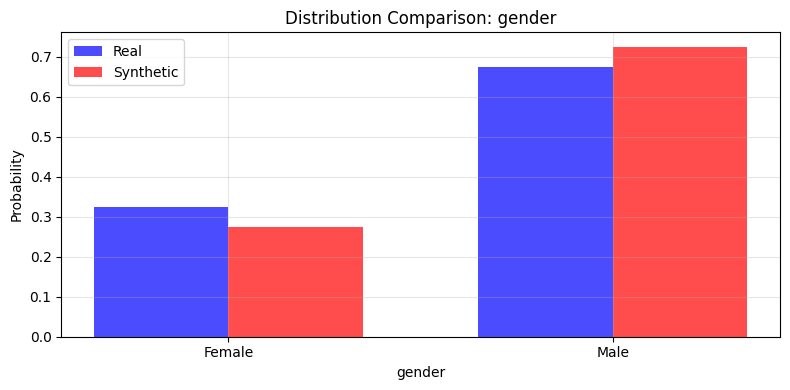

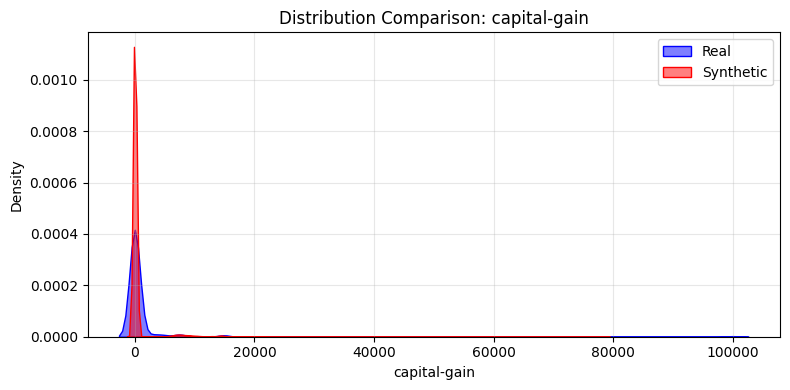

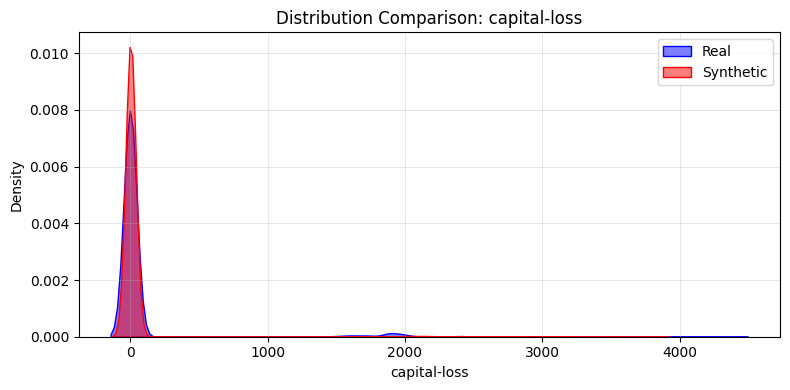

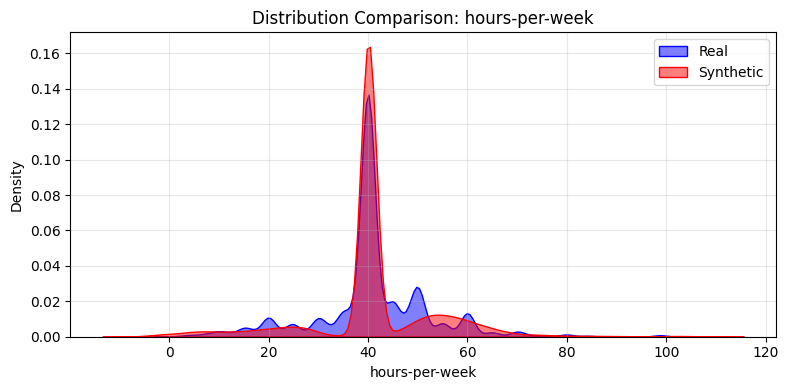

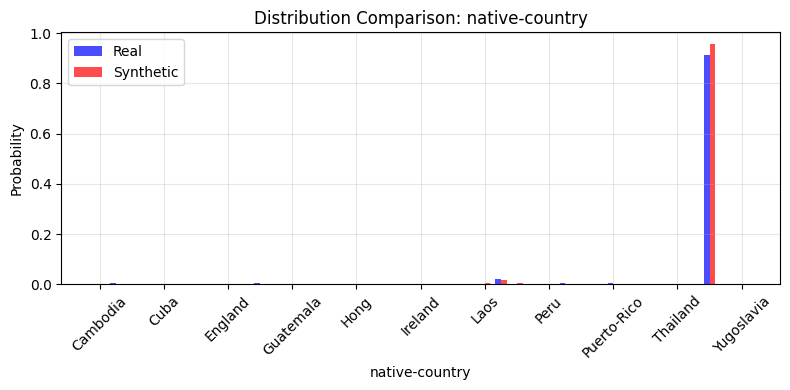

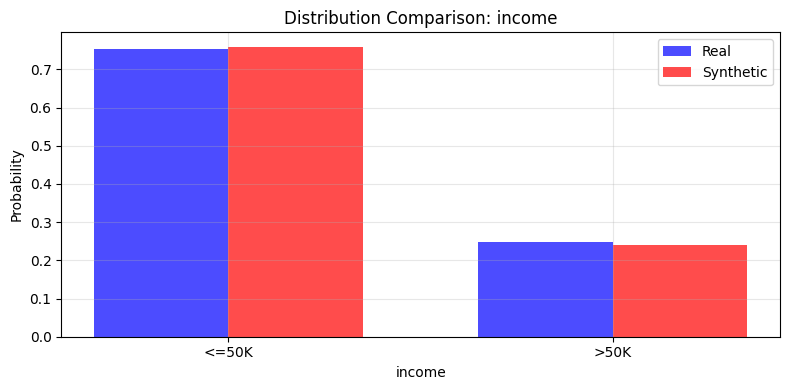

✅ Distribution plots completed


In [ ]:
print("\nPlotting distribution comparisons...")
for col in df.columns:
    plt.figure(figsize=(8, 4))
    
    if col in num_cols:
        sns.kdeplot(df[col], label='Real', fill=True, alpha=0.5, color='blue')
        sns.kdeplot(syn_df[col], label='Synthetic', fill=True, alpha=0.5, color='red')
    else:
        real_counts = df[col].value_counts(normalize=True)
        syn_counts = syn_df[col].value_counts(normalize=True)
    
        all_categories = sorted(set(real_counts.index) | set(syn_counts.index))
        real_counts = real_counts.reindex(all_categories, fill_value=0)
        syn_counts = syn_counts.reindex(all_categories, fill_value=0)
        
        x = np.arange(len(all_categories))
        width = 0.35
        
        plt.bar(x - width/2, real_counts.values, width, label='Real', alpha=0.7, color='blue')
        plt.bar(x + width/2, syn_counts.values, width, label='Synthetic', alpha=0.7, color='red')
        
        if len(all_categories) <= 20:
            plt.xticks(x, all_categories, rotation=45 if len(all_categories) > 10 else 0)
        else:
            step = max(1, len(all_categories) // 10)
            plt.xticks(x[::step], [all_categories[i] for i in range(0, len(all_categories), step)], rotation=45)
    
    plt.title(f'Distribution Comparison: {col}')
    plt.xlabel(col)
    plt.ylabel('Density' if col in num_cols else 'Probability')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f'dist_comparison_{col}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

print("✅ Distribution plots completed")

In [ ]:
def compute_histogram_probs(data, bins=50, range_vals=None):
    if range_vals is None:
        range_vals = (data.min(), data.max())
    
    hist, _ = np.histogram(data, bins=bins, range=range_vals, density=True)
    hist = hist + 1e-10 
    hist = hist / hist.sum()
    return hist

def kl_divergence(real_data, syn_data, bins=50):
    min_val = min(real_data.min(), syn_data.min())
    max_val = max(real_data.max(), syn_data.max())
    range_vals = (min_val, max_val)
    p = compute_histogram_probs(real_data, bins=bins, range_vals=range_vals)
    q = compute_histogram_probs(syn_data, bins=bins, range_vals=range_vals)
    kl = entropy(p, q)
    return kl

def js_divergence(real_data, syn_data, bins=50):
    min_val = min(real_data.min(), syn_data.min())
    max_val = max(real_data.max(), syn_data.max())
    range_vals = (min_val, max_val)
    p = compute_histogram_probs(real_data, bins=bins, range_vals=range_vals)
    q = compute_histogram_probs(syn_data, bins=bins, range_vals=range_vals)
    js = jensenshannon(p, q, base=2)
    return js

def compute_divergences_for_dataframes(df_real, df_syn, num_cols, cat_cols, bins=50):
    results = {
        'column': [],
        'type': [],
        'kl_divergence': [],
        'js_divergence': []
    }
    for col in num_cols:
        real_vals = df_real[col].values
        syn_vals = df_syn[col].values
        
        kl = kl_divergence(real_vals, syn_vals, bins=bins)
        js = js_divergence(real_vals, syn_vals, bins=bins)
        
        results['column'].append(col)
        results['type'].append('numeric')
        results['kl_divergence'].append(kl)
        results['js_divergence'].append(js)

    for col in cat_cols:
        real_counts = df_real[col].value_counts(sort=False)
        syn_counts = df_syn[col].value_counts(sort=False)
        all_cats = sorted(set(real_counts.index) | set(syn_counts.index))
        p = np.array([real_counts.get(c, 0) for c in all_cats]) + 1e-10
        q = np.array([syn_counts.get(c, 0) for c in all_cats]) + 1e-10
        p = p / p.sum()
        q = q / q.sum()
        kl = entropy(p, q)
        js = jensenshannon(p, q, base=2)
        
        results['column'].append(col)
        results['type'].append('categorical')
        results['kl_divergence'].append(kl)
        results['js_divergence'].append(js)
    
    return pd.DataFrame(results)


EVALUATION: STATISTICAL TESTS

Kolmogorov-Smirnov Test (Numeric Columns):
------------------------------------------------------------
age                 : KS statistic = 0.0496, p-value = 0.000000
fnlwgt              : KS statistic = 0.0535, p-value = 0.000000
educational-num     : KS statistic = 0.2378, p-value = 0.000000
capital-gain        : KS statistic = 0.6767, p-value = 0.000000
capital-loss        : KS statistic = 0.8955, p-value = 0.000000
hours-per-week      : KS statistic = 0.4354, p-value = 0.000000

------------------------------------------------------------

Chi-Squared Test (Categorical Columns):
------------------------------------------------------------
workclass           : χ² = 2487.3626, p-value = 0.000000
education           : χ² = 4054.3236, p-value = 0.000000
marital-status      : χ² = 1540.4694, p-value = 0.000000
occupation          : χ² = 5617.4309, p-value = 0.000000
relationship        : χ² = 1497.1206, p-value = 0.000000
race                : χ² = 1346

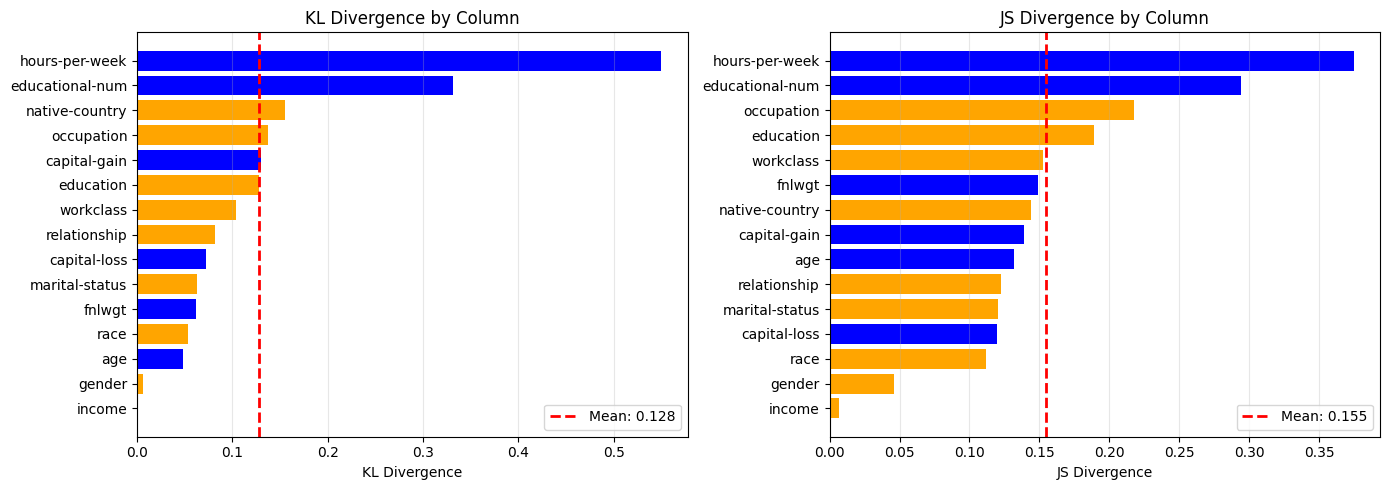

In [ ]:
print("\n" + "="*80)
print("EVALUATION: STATISTICAL TESTS")
print("="*80 + "\n")
print("Kolmogorov-Smirnov Test (Numeric Columns):")
print("-" * 60)
for col in num_cols:
    ks_stat, p_value = ks_2samp(df[col], syn_df[col])
    print(f"{col:20s}: KS statistic = {ks_stat:.4f}, p-value = {p_value:.6f}")

print("\n" + "-" * 60 + "\n")
print("Chi-Squared Test (Categorical Columns):")
print("-" * 60)
for col in cat_cols:
    real_counts = df[col].value_counts()
    synth_counts = syn_df[col].value_counts()
    table = pd.concat([real_counts, synth_counts], axis=1).fillna(0)
    chi2, p, dof, expected = chi2_contingency(table.T)
    print(f"{col:20s}: χ² = {chi2:.4f}, p-value = {p:.6f}")

print("\n" + "="*80)
print("EVALUATION: KL AND JS DIVERGENCE")
print("="*80 + "\n")

divergence_results = compute_divergences_for_dataframes(df, syn_df, num_cols, cat_cols, bins=50)

print("KL and JS Divergence for all columns:")
print("-" * 80)
print(divergence_results.to_string(index=False))

divergence_results.to_csv(os.path.join(out_dir, "divergence_results.csv"), index=False)

print("\n" + "-" * 80)
print("\nSummary Statistics:")
print(f"Average KL Divergence: {divergence_results['kl_divergence'].mean():.4f}")
print(f"Average JS Divergence: {divergence_results['js_divergence'].mean():.4f}")
print(f"\nMedian KL Divergence: {divergence_results['kl_divergence'].median():.4f}")
print(f"Median JS Divergence: {divergence_results['js_divergence'].median():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

divergence_results_sorted = divergence_results.sort_values('kl_divergence')
axes[0].barh(divergence_results_sorted['column'], divergence_results_sorted['kl_divergence'], 
             color=['blue' if t == 'numeric' else 'orange' for t in divergence_results_sorted['type']])
axes[0].set_xlabel('KL Divergence')
axes[0].set_title('KL Divergence by Column')
axes[0].grid(True, alpha=0.3, axis='x')
axes[0].axvline(divergence_results['kl_divergence'].mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {divergence_results["kl_divergence"].mean():.3f}')
axes[0].legend()

divergence_results_sorted = divergence_results.sort_values('js_divergence')
axes[1].barh(divergence_results_sorted['column'], divergence_results_sorted['js_divergence'],
             color=['blue' if t == 'numeric' else 'orange' for t in divergence_results_sorted['type']])
axes[1].set_xlabel('JS Divergence')
axes[1].set_title('JS Divergence by Column')
axes[1].grid(True, alpha=0.3, axis='x')
axes[1].axvline(divergence_results['js_divergence'].mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {divergence_results["js_divergence"].mean():.3f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(out_dir, "divergence_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import json
import numpy as np
import pandas as pd
from itertools import combinations
from typing import List, Tuple, Dict

from scipy.stats import ks_2samp, pearsonr
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from tqdm import tqdm

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# ---------- small helpers ----------
def total_variation_distance_counts(real_counts: np.ndarray, synth_counts: np.ndarray) -> float:
    p = real_counts.astype(float) / (real_counts.sum() + 1e-12)
    q = synth_counts.astype(float) / (synth_counts.sum() + 1e-12)
    return float(np.abs(p - q).sum())

# ---------- column fidelity ----------
def column_fidelity(real_df: pd.DataFrame, synth_df: pd.DataFrame,
                    categorical_cols: List[str], numeric_cols: List[str]) -> Tuple[Dict, float]:
    per_col = {}
    for col in numeric_cols:
        a = real_df[col].dropna().values
        b = synth_df[col].dropna().values
        if len(a) == 0 or len(b) == 0:
            ks_stat = 1.0
        else:
            ks_stat = ks_2samp(a, b).statistic
        omega = 1.0 - float(ks_stat)
        per_col[col] = {"type": "numeric", "ks": float(ks_stat), "omega_col": float(omega)}

    for col in categorical_cols:
        a = real_df[col].astype(str).fillna("__nan__").values
        b = synth_df[col].astype(str).fillna("__nan__").values
        real_counts = pd.Series(a).value_counts().sort_index()
        synth_counts = pd.Series(b).value_counts().reindex(real_counts.index, fill_value=0)
        tvd = total_variation_distance_counts(real_counts.values, synth_counts.values)
        omega = 1.0 - 0.5 * float(tvd)
        per_col[col] = {"type": "categorical", "tvd": float(tvd), "omega_col": float(omega)}

    Omega_col = float(np.mean([v["omega_col"] for v in per_col.values()]))
    return per_col, Omega_col

# ---------- row fidelity ----------
def compute_pairwise_row_fidelity(real_df: pd.DataFrame, synth_df: pd.DataFrame,
                                  categorical_cols: List[str], numeric_cols: List[str]) -> Tuple[Dict, float]:
    per_pair = {}
    scores = []

    # numeric-numeric pairs
    for a, b in combinations(numeric_cols, 2):
        ra = real_df[a].dropna().values
        rb = real_df[b].dropna().values
        sa = synth_df[a].dropna().values
        sb = synth_df[b].dropna().values
        try:
            rho_real = float(pearsonr(ra, rb)[0])
        except Exception:
            rho_real = 0.0
        try:
            rho_synth = float(pearsonr(sa, sb)[0])
        except Exception:
            rho_synth = 0.0
        delta = abs(rho_real - rho_synth)
        omega = 1.0 - 0.5 * delta
        per_pair[(a,b)] = {"type": "num-num", "rho_real": rho_real, "rho_synth": rho_synth, "omega_row": float(omega)}
        scores.append(omega)

    # categorical-categorical pairs (joint TVD)
    for a, b in combinations(categorical_cols, 2):
        ra = real_df[[a,b]].astype(str).fillna("__nan__")
        sa = synth_df[[a,b]].astype(str).fillna("__nan__")
        real_joint = ra.value_counts().sort_index()
        synth_joint = sa.value_counts().reindex(real_joint.index, fill_value=0)
        tvd = total_variation_distance_counts(real_joint.values, synth_joint.values)
        omega = 1.0 - 0.5 * float(tvd)
        per_pair[(a,b)] = {"type": "cat-cat", "tvd_joint": float(tvd), "omega_row": float(omega)}
        scores.append(omega)

    Omega_row = float(np.mean(scores)) if len(scores) > 0 else 0.0
    return per_pair, Omega_row

# ---------- DCR (privacy) ----------
def compute_DCR(real_df: pd.DataFrame, synth_df: pd.DataFrame,
                categorical_cols: List[str], numeric_cols: List[str]) -> float:
    scaler = StandardScaler()
    real_nums = real_df[numeric_cols].astype(float).fillna(0.0).values if len(numeric_cols)>0 else np.zeros((len(real_df),0))
    synth_nums = synth_df[numeric_cols].astype(float).fillna(0.0).values if len(numeric_cols)>0 else np.zeros((len(synth_df),0))
    if real_nums.shape[1] > 0:
        scaler.fit(real_nums)
        real_nums_s = scaler.transform(real_nums)
        synth_nums_s = scaler.transform(synth_nums)
    else:
        real_nums_s = np.zeros((len(real_df),0))
        synth_nums_s = np.zeros((len(synth_df),0))

    enc = OneHotEncoder(handle_unknown="ignore",sparse_output=False)
    if len(categorical_cols) > 0:
        real_cats = real_df[categorical_cols].astype(str).fillna("__nan__").values
        synth_cats = synth_df[categorical_cols].astype(str).fillna("__nan__").values
        enc.fit(real_cats)
        real_cats_ohe = enc.transform(real_cats)
        synth_cats_ohe = enc.transform(synth_cats)
    else:
        real_cats_ohe = np.zeros((len(real_df),0))
        synth_cats_ohe = np.zeros((len(synth_df),0))

    real_matrix = np.hstack([real_nums_s, real_cats_ohe])
    synth_matrix = np.hstack([synth_nums_s, synth_cats_ohe])

    nn = NearestNeighbors(n_neighbors=1, algorithm='auto', metric='euclidean')
    nn.fit(real_matrix)
    dists, _ = nn.kneighbors(synth_matrix, n_neighbors=1, return_distance=True)
    median_dcr = float(np.median(dists.ravel()))
    return median_dcr

# ---------- synthesis (exact match) ----------
def compute_synthesis(real_df: pd.DataFrame, synth_df: pd.DataFrame,
                      categorical_cols: List[str], numeric_cols: List[str]) -> float:
    if len(categorical_cols) > 0:
        real_cat_keys = real_df[categorical_cols].astype(str).fillna("__nan__").agg("||".join, axis=1)
        synth_cat_keys = synth_df[categorical_cols].astype(str).fillna("__nan__").agg("||".join, axis=1)
        groups = {}
        for idx, key in enumerate(real_cat_keys):
            groups.setdefault(key, []).append(idx)
    else:
        real_cat_keys = pd.Series(["_all_"] * len(real_df))
        synth_cat_keys = pd.Series(["_all_"] * len(synth_df))
        groups = {"_all_": list(range(len(real_df)))}

    real_nums = real_df[numeric_cols].astype(float).fillna(0.0).values
    synth_nums = synth_df[numeric_cols].astype(float).fillna(0.0).values

    matched = 0
    for i, key in enumerate(synth_cat_keys):
        candidate_idxs = groups.get(key, [])
        if len(candidate_idxs) == 0:
            continue
        s_vals = synth_nums[i] if len(numeric_cols)>0 else np.array([])
        r_vals = real_nums[candidate_idxs] if len(numeric_cols)>0 else np.array([[]])
        if r_vals.size == 0 and s_vals.size == 0:
            matched += 1
            continue
        abs_diffs = np.abs(r_vals - s_vals[None, :])
        rel_bounds = 0.01 * (np.abs(r_vals) + 1e-12)
        within = (abs_diffs <= rel_bounds) | (abs_diffs <= 1e-6)
        row_all = within.all(axis=1)
        if row_all.any():
            matched += 1
    return float(matched / len(synth_df))

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

def compute_utility_accuracy(real_test_df: pd.DataFrame,
                             synth_train_df: pd.DataFrame,
                             label_col: str):

    models = {
        "RandomForest": RandomForestClassifier(
            n_estimators=300,
            max_depth=15,
            min_samples_split=4,
            min_samples_leaf=2,
            max_features="sqrt",
            bootstrap=True,
            n_jobs=-1,
            random_state=42
        ),
        "DecisionTree": DecisionTreeClassifier(
            max_depth=10,
            min_samples_split=5,
            min_samples_leaf=3,
            random_state=42
        ),
        "LogisticRegression": LogisticRegression(
            max_iter=1000,
            solver="lbfgs"
        ),
        "AdaBoost": AdaBoostClassifier(
            n_estimators=200,
            learning_rate=0.5,
            random_state=42
        )
    }

    # Align columns
    synth_train_df = synth_train_df[real_test_df.columns]

    X_train = synth_train_df.drop(columns=[label_col])
    y_train = synth_train_df[label_col]

    X_test = real_test_df.drop(columns=[label_col])
    y_test = real_test_df[label_col]

    # Identify categorical & numeric columns automatically
    categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
    numeric_cols = X_train.select_dtypes(exclude=["object"]).columns.tolist()

    # Preprocessing pipeline
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", "passthrough", numeric_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
        ]
    )

    accuracies = []
    results = {}

    for name, model in models.items():
        clf = Pipeline(steps=[
            ("preprocess", preprocessor),
            ("model", model)
        ])

        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        acc = accuracy_score(y_test, preds)

        results[name] = acc
        accuracies.append(acc)

    return results, float(np.mean(accuracies))


In [29]:

real_df = df
synth_df = syn_df


print("Computing column fidelity...")
per_col, Omega_col = column_fidelity(real_df, synth_df, cat_cols, num_cols)

print("Computing row fidelity (pairwise)...")
per_pair, Omega_row = compute_pairwise_row_fidelity(real_df, synth_df, cat_cols, num_cols)

print("Computing privacy (DCR median)...")
median_dcr = compute_DCR(real_df, synth_df, cat_cols, num_cols)

print("Computing synthesis fraction (exact/1% matches)...")
synth_frac = compute_synthesis(real_df, synth_df, cat_cols, num_cols)

print("Computing utility (train on synth, test on real)...")
utility_per_clf, utility_mean = compute_utility_accuracy(real_df, synth_df,label_col)

# Summarize
summary = {
    "Omega_col": Omega_col,
    "Omega_row": Omega_row,
    "privacy_median_DCR": median_dcr,
    "synthesis_fraction": synth_frac,
    "utility_mean_accuracy": utility_mean,
    "utility_per_classifier": utility_per_clf
}

print("\n=== Evaluation Summary ===")
print(f"Omega_col (column fidelity avg): {Omega_col:.4f}")
print(f"Omega_row (row fidelity avg):    {Omega_row:.4f}")
print(f"Privacy (median DCR):            {median_dcr:.6f}")
print(f"Utility (mean accuracy):         {utility_mean:.4f}")
print(f"Synthesis (match frac):          {synth_frac:.6f}")

Computing column fidelity...
Computing row fidelity (pairwise)...
Computing privacy (DCR median)...
Computing synthesis fraction (exact/1% matches)...
Computing utility (train on synth, test on real)...

=== Evaluation Summary ===
Omega_col (column fidelity avg): 0.7942
Omega_row (row fidelity avg):    0.8955
Privacy (median DCR):            0.508131
Utility (mean accuracy):         0.7821
Synthesis (match frac):          0.000000


In [ ]:
out_json = "eval_results.json"
out_csv = "eval_per_column.csv"

# write JSON
with open(out_json, "w") as f:
    json.dump({
        "summary": summary,
        "per_column": per_col,
        "per_pair": {str(k):v for k,v in per_pair.items()}
    }, f, indent=2)
print("Saved evaluation JSON:", out_json)

# optional: save per-column table
per_col_df = pd.DataFrame.from_dict(per_col, orient="index")
per_col_df.to_csv(out_csv)
print("Saved per-column CSV:", out_csv)

Saved evaluation JSON: eval_results.json
Saved per-column CSV: eval_per_column.csv


In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
real_df=df

syn_df=syn_df
real_train, real_test = train_test_split(
    real_df,
    test_size=0.2,
    random_state=42
)
categorical_cols=cat_cols

In [32]:
from sklearn.preprocessing import OrdinalEncoder
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.metrics import accuracy_score, mean_squared_error
import numpy as np


def compute_structural_fidelity_tabstruct(
    real_df,
    synthetic_df,
    test_size=0.2,
    random_state=42,
):

    feature_scores = {}

    for target in real_df.columns:
        print("Evaluating target:", target)

        X_train_syn = synthetic_df.drop(columns=[target]).copy()
        y_train_syn = synthetic_df[target]

        X_test_real = real_df.drop(columns=[target]).copy()
        y_test_real = real_df[target]

        # Identify categorical columns excluding current target
        cat_cols_current = [c for c in categorical_cols if c != target]

        # Fit encoder ONLY on synthetic training
        if len(cat_cols_current) > 0:
            encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

            encoder.fit(X_train_syn[cat_cols_current])

            X_train_syn[cat_cols_current] = encoder.transform(X_train_syn[cat_cols_current])
            X_test_real[cat_cols_current] = encoder.transform(X_test_real[cat_cols_current])

        # Convert everything to numeric
        X_train_syn = X_train_syn.astype(float)
        X_test_real = X_test_real.astype(float)

        # ---------- Classification ----------
        if target in categorical_cols:
            model = LGBMClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=-1,
                random_state=random_state,
                verbose=-1
            )

            model.fit(X_train_syn, y_train_syn)
            y_pred = model.predict(X_test_real)
            score = accuracy_score(y_test_real, y_pred)

        # ---------- Regression ----------
        else:
            model = LGBMRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=-1,
                random_state=random_state,
                verbose=-1
            )

            model.fit(X_train_syn, y_train_syn)
            y_pred = model.predict(X_test_real)
            score = np.sqrt(mean_squared_error(y_test_real, y_pred))

        feature_scores[target] = score

    return feature_scores

In [33]:
perf_syn= compute_structural_fidelity_tabstruct(
    real_test,
    syn_df
)

perf_real= compute_structural_fidelity_tabstruct(
    real_test,
    real_train
)

Evaluating target: age
Evaluating target: workclass
Evaluating target: fnlwgt
Evaluating target: education
Evaluating target: educational-num
Evaluating target: marital-status
Evaluating target: occupation
Evaluating target: relationship
Evaluating target: race
Evaluating target: gender
Evaluating target: capital-gain
Evaluating target: capital-loss
Evaluating target: hours-per-week
Evaluating target: native-country
Evaluating target: income
Evaluating target: age
Evaluating target: workclass
Evaluating target: fnlwgt
Evaluating target: education
Evaluating target: educational-num
Evaluating target: marital-status
Evaluating target: occupation
Evaluating target: relationship
Evaluating target: race
Evaluating target: gender
Evaluating target: capital-gain
Evaluating target: capital-loss
Evaluating target: hours-per-week
Evaluating target: native-country
Evaluating target: income


In [34]:
print("Performance Scores Synthetic:", perf_syn)
print("Performance Scores Real:", perf_real)

Performance Scores Synthetic: {'age': np.float64(12.247950733523172), 'workclass': 0.5775566611387507, 'fnlwgt': np.float64(117475.17574329552), 'education': 0.33930348258706466, 'educational-num': np.float64(0.37200643031002173), 'marital-status': 0.7593145384190161, 'occupation': 0.23548922056384744, 'relationship': 0.7480375898286346, 'race': 0.7991155334438916, 'gender': 0.8027639579878386, 'capital-gain': np.float64(7347.236834016178), 'capital-loss': np.float64(420.68179890103306), 'hours-per-week': np.float64(21.128189543879127), 'native-country': 0.9084577114427861, 'income': 0.7383084577114428}
Performance Scores Real: {'age': np.float64(9.716009063279094), 'workclass': 0.7542288557213931, 'fnlwgt': np.float64(102203.38777671111), 'education': 1.0, 'educational-num': np.float64(0.11953752825811241), 'marital-status': 0.8512990602542841, 'occupation': 0.3589828634604754, 'relationship': 0.7992260917634052, 'race': 0.8824765063571034, 'gender': 0.8563847429519071, 'capital-gain'

In [35]:
def compute_utilities(per_feature, per_feature_real, target_variable):
    per_feature_utility = {}
    for feature in per_feature:
        synth_perf = per_feature[feature]
        real_perf = per_feature_real[feature]

        if feature in categorical_cols:
            utility = synth_perf / real_perf
        else:
            utility = real_perf / synth_perf
        per_feature_utility[feature] = utility
    global_utility = sum(per_feature_utility.values()) / len(per_feature_utility)
    local_utility = per_feature_utility[target_variable]
    return global_utility, local_utility, per_feature_utility

In [36]:
global_utility, local_utility, per_feature_utility=compute_utilities(perf_syn, perf_real,label_col)
print(f"Global Utility: {global_utility}")
print(f"Local Utility: {local_utility}")
print(f"Per Feature Utility: {per_feature_utility}")

Global Utility: 0.7815254455772384
Local Utility: 0.8457446808510638
Per Feature Utility: {'age': np.float64(0.7932763018621519), 'workclass': 0.7657578422749927, 'fnlwgt': np.float64(0.8699998712923314), 'education': 0.33930348258706466, 'educational-num': np.float64(0.321331887081878), 'marital-status': 0.891948051948052, 'occupation': 0.6559901447489991, 'relationship': 0.9359524138885046, 'race': 0.9055374592833876, 'gender': 0.9373870384714692, 'capital-gain': np.float64(0.9674777761787093), 'capital-loss': np.float64(0.9345203166632249), 'hours-per-week': np.float64(0.48509810610082593), 'native-country': 1.0735563104259211, 'income': 0.8457446808510638}
